In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# Step 1: Loading the dataset - California House Pricing Dataset

In [3]:
from sklearn.datasets import fetch_california_housing

In [7]:
california = fetch_california_housing()

In [8]:
type(california)
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [12]:
# Let's check the description of the dataset
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [13]:
print(california.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [14]:
print(california.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [15]:
print(california.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


# Step 2: Exploratory Data Analysis



In [22]:
# preparing the dataset
dataset = pd.DataFrame(
                      california.data,
                      columns = california.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [23]:
dataset['Price'] = california.target
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [24]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [26]:
# summarizing the stats of the data
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [30]:
# Check the missing values
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [34]:
# Correlation
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


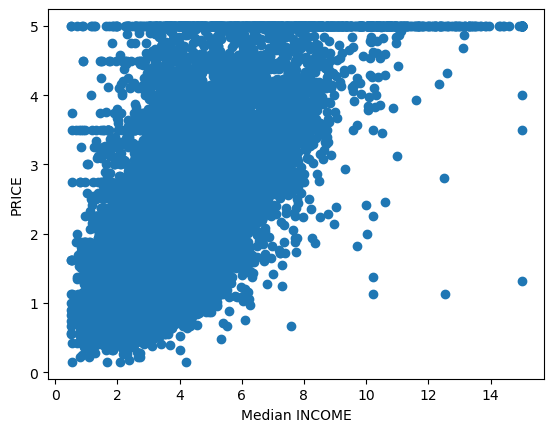

In [43]:

plt.scatter(dataset['MedInc'],dataset['Price'])
plt.xlabel('Median INCOME')
plt.ylabel('PRICE')
plt.show()

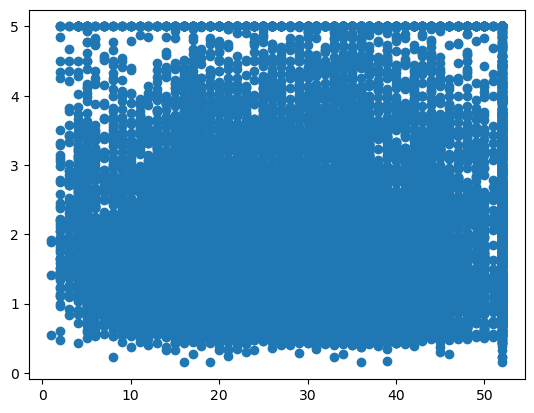

In [44]:
plt.scatter(dataset['HouseAge'],dataset['Price'])
plt.show()

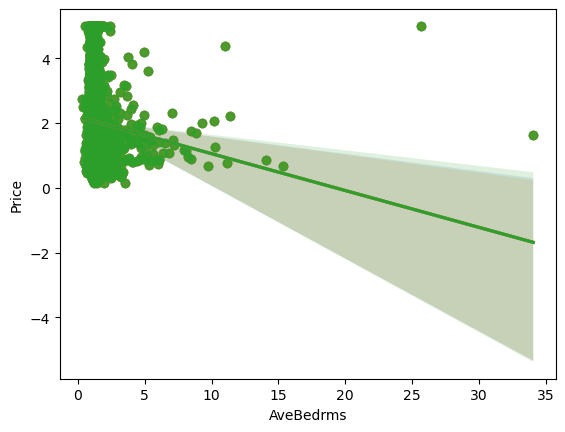

In [48]:
import seaborn as sns
sns.regplot(x='AveBedrms', y='Price',data=dataset)
plt.show()

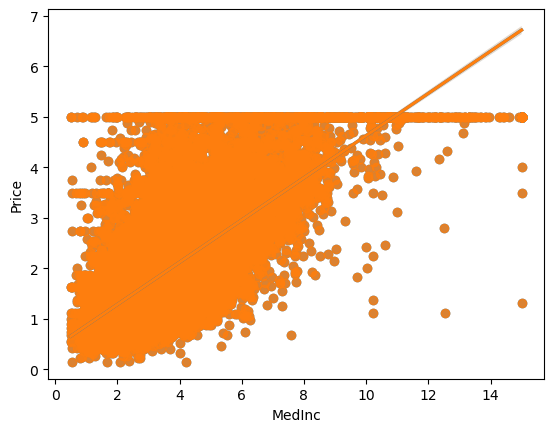

In [50]:
sns.regplot(x='MedInc',y='Price',data=dataset)
plt.show()

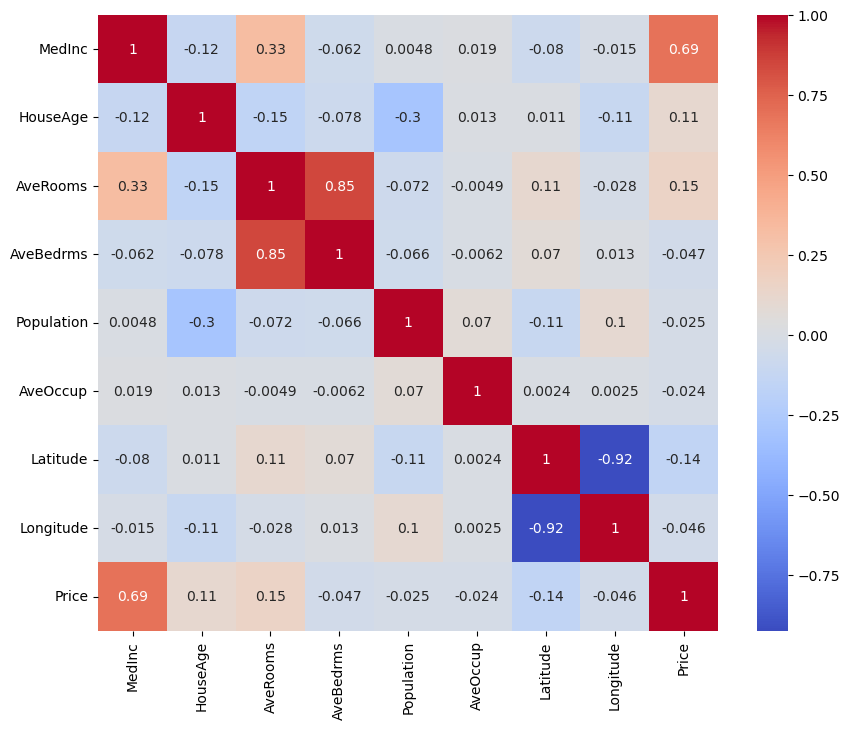

In [60]:
plt.figure(figsize=(10,8))

sns.heatmap(
    dataset.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

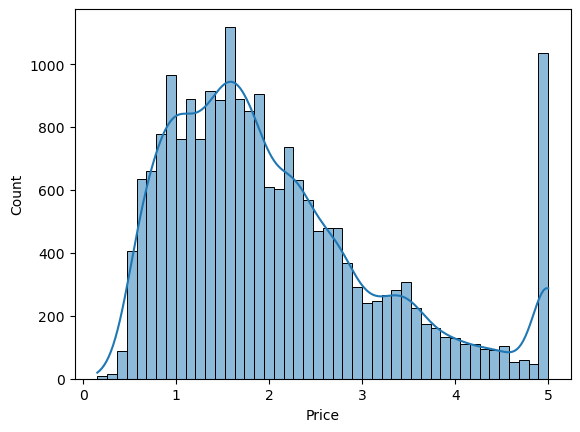

In [53]:
# distribution plot
sns.histplot(dataset['Price'],kde=True)
plt.show()

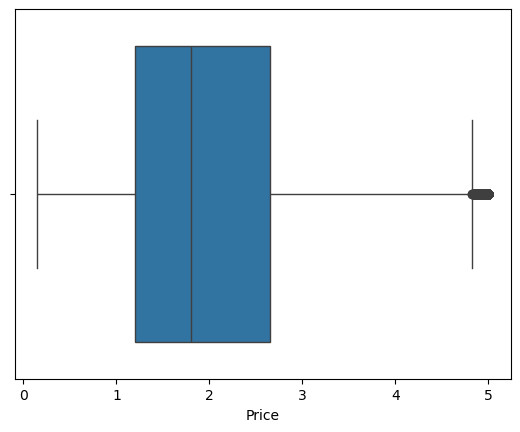

In [61]:
#boxplot
sns.boxplot(
    x=dataset['Price']
)
plt.show()

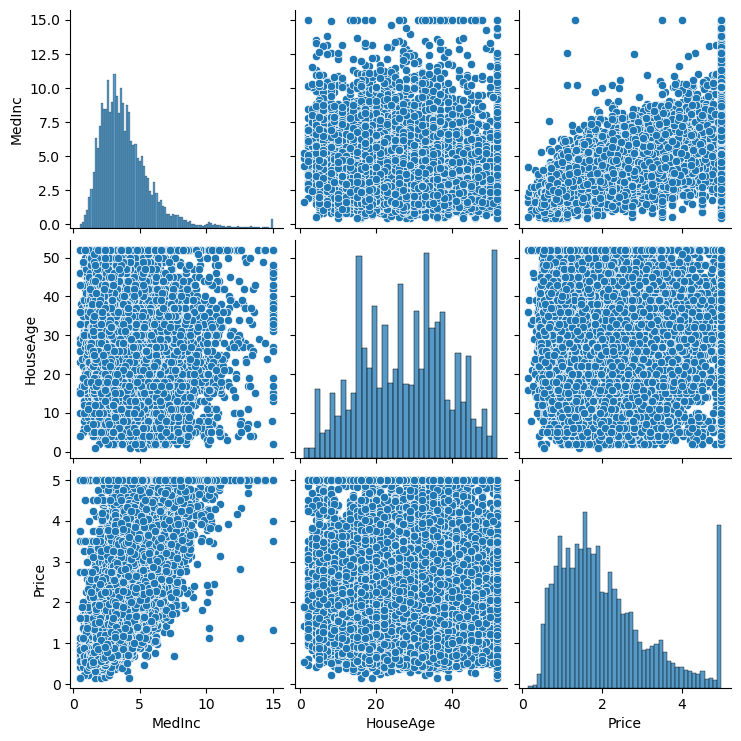

In [64]:
sns.pairplot(dataset[[
    "MedInc",
    "HouseAge",
    "Price"
]])

plt.show()

# Step 3: Dependent and independent features

In [71]:
X = dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [70]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Price, Length: 20640, dtype: float64

In [74]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3,random_state=42)

# Step 4: Standardlize the dataset 

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Training the model

In [78]:
from sklearn.linear_model import LinearRegression 
regression=LinearRegression()

regression.fit(X_train, y_train)

LinearRegression()

In [100]:
# print the coefficients and the intercept 
print(np.round(regression.coef_, 3))
print(np.round(regression.intercept_,3))

[ 0.849  0.122 -0.3    0.348 -0.001 -0.042 -0.894 -0.869]
2.069


In [101]:
# on which parameters the model has been trained
regression.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [102]:
# prediction with test data
reg_pred = regression.predict(X_test)
reg_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

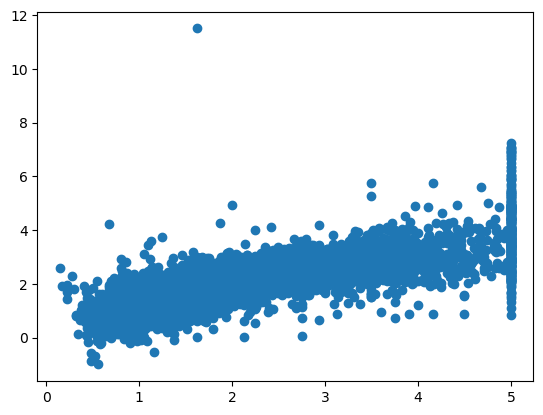

In [103]:
#plot a scatter plot for the prediction
plt.scatter(y_test,reg_pred)
plt.show()

In [104]:
# prediction with residuals 
residuals = y_test - reg_pred 
residuals

20046   -0.249049
3024    -1.309434
15663    2.289088
20484   -0.649147
9814     0.173042
           ...   
17505    0.155059
13512   -0.237516
10842    0.109345
16559   -0.379714
5786     0.270559
Name: Price, Length: 6192, dtype: float64

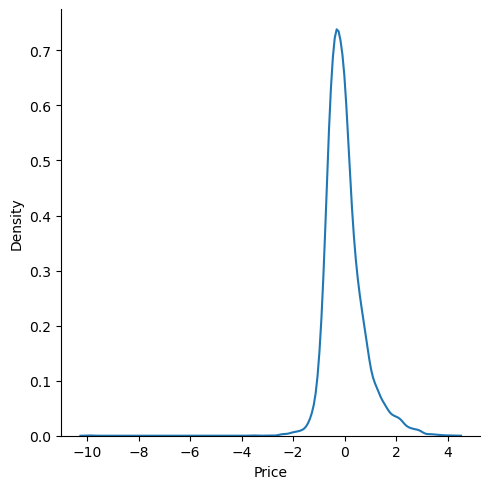

In [105]:
# plotting these residuals
sns.displot(residuals, kind ="kde")
plt.show()

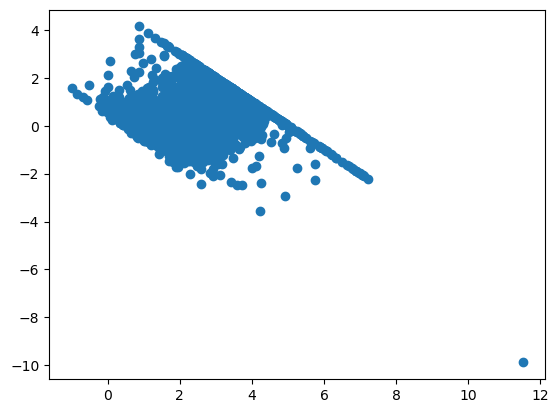

In [106]:
# scatter plot w respect to predictions and residuals
plt.scatter(reg_pred, residuals)
plt.show()

In [108]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
mse_lr = mean_squared_error(y_test,reg_pred)
rmse_lr = np.sqrt(mse_lr)

r2_lr=r2_score(y_test, reg_pred)

print("------Linear Regression-------")
print("MSE :", round(mse_lr,3))
print("RMSE : ",round(rmse_lr, 3))
print("R2 : ", round(r2_lr,3))


------Linear Regression-------
MSE : 0.531
RMSE :  0.728
R2 :  0.596


The residual plot shows a downward trend indicating that linear regression is not the best model for this dataset. This model overestimates cheap houses and underestimates expensive houses. This is likely due to the $500,000 price cap in the california housing dataset. 
Moving to Random Forest to handle non linearity better.

This is called Heteroscedasticity : errors are not random, they follow a pattern .
.
ALSO, Linear Regression gave an R2 of 0.596 meaning it could only 
explain 59% of the variance in house prices. 

This is because house prices have a non linear relationship 
with features — Linear Regression cannot capture this.

# Step 6: Random Forest

In [109]:
from sklearn.ensemble import RandomForestRegressor

rf= RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_pred

array([0.47812  , 0.7259   , 4.8233256, ..., 2.0254501, 1.38122  ,
       2.14114  ])

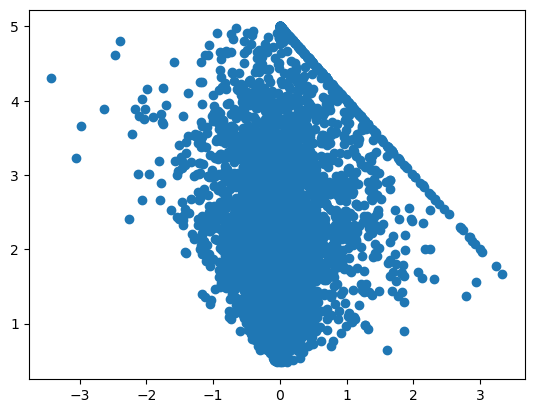

In [111]:
residuals = y_test-rf_pred
residuals
plt.scatter(
    residuals,rf_pred
)
plt.show()

In [116]:
# random forest metrics
n = X_test.shape[0]   # number of rows
k = X_test.shape[1]   # number of features

mse_rf = mean_squared_error(y_test, rf_pred)
rmse_rf = np.sqrt(mse_rf)

r2_rf=r2_score(y_test, rf_pred)
adjusted_r2 = 1 - (1 - r2_rf) * (n - 1) / (n - k - 1)

print("-----Random Forest-----")
print("MSE : ", round(mse_rf,3))
print("RMSE : " , round(rmse_rf,3))
print("R2:",round(r2_rf,3))
print("Adjusted R2 Score :", round(adjusted_r2, 3))

-----Random Forest-----
MSE :  0.257
RMSE :  0.507
R2: 0.804
Adjusted R2 Score : 0.804


Switching to Random Forest improved R2 to 0.804, explaining 
80% of variance. This confirms that tree based models handle this dataset better 
due to their ability to capture non linear patterns.

# Step 7: Prediction on new data

In [129]:
california.data[0].reshape(1,-1).shape

(1, 8)

In [131]:
rf.predict(california.data[0].reshape(1,-1))

array([3.6101138])

In [134]:
# comparing it with actual values:

print("Actual: ", california.target[0])
print(
    "Predicted : ", rf.predict(
        california.data[0].reshape(1,-1)
)
)

Actual:  4.526
Predicted :  [3.6101138]


In [139]:
# for more rows of data:
results = pd.DataFrame({
    "Actual  ": y_test,
    "Predicted ": rf_pred
})
print(results.head(20))

       Actual    Predicted 
20046   0.47700    0.478120
3024    0.45800    0.725900
15663   5.00001    4.823326
20484   2.18600    2.599520
9814    2.78000    2.317750
13311   1.58700    1.690840
7113    1.98200    2.383790
7668    1.57500    1.651630
18246   3.40000    2.730030
5723    4.46600    4.888738
20069   1.23200    1.151650
6835    2.53900    1.999080
11351   2.15100    1.621190
20267   2.20500    1.791000
7097    2.19800    2.478230
6298    1.36200    1.598980
696     1.78400    1.962050
19607   1.87500    1.906350
14173   1.39800    1.488210
19638   1.37500    0.944920


# Step 8: Feature importance tuning

In [143]:
importances = rf.feature_importances_
features = X.columns
X_train.shape

feat_df = pd.DataFrame({
    "features":features,
    "importances" : importances
})
feat_df =feat_df.sort_values(by="importances",ascending=False)
print(feat_df)

     features  importances
0      MedInc     0.526068
5    AveOccup     0.138302
7   Longitude     0.086108
6    Latitude     0.086096
1    HouseAge     0.054723
2    AveRooms     0.047003
4  Population     0.031767
3   AveBedrms     0.029933


Removing the population and aveBedrms bc they have low importance. Then retrain and compare R2


# Step 9: Retraining the Random Forest

In [149]:
important_features = [0,5,7,6,1,2]

X_train_new = X_train[:,important_features]
X_test_new = X_test[:,important_features]


In [158]:
rf2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf2.fit(X_train_new,y_train)

rf2_pred = rf2.predict(X_test_new)
rf2_pred

array([0.49126  , 0.72482  , 4.9176949, ..., 2.2910302, 1.34331  ,
       2.34503  ])

In [151]:
print("Old R2:" ,r2_score(y_test, rf_pred))
print("New R2:", r2_score(y_test, rf2_pred))

Old R2: 0.8039579431052819
New R2: 0.8062420598451774


After removing low-importance features such as Population and AveBedrms, the model’s R² score improved from 0.804 to 0.806, showing slightly better predictive performance.


# Step 10: Pickling the model file for Deployment

In [152]:
import pickle

In [154]:
# save model
pickle.dump(rf2, open("housing_model.pkl","wb"))

In [156]:
# loading
pickled_model = pickle.load(open('housing_model.pkl','rb'))

In [159]:
#prediction
pickled_model.predict(X_test_new)

array([0.49126  , 0.72482  , 4.9176949, ..., 2.2910302, 1.34331  ,
       2.34503  ])